<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Learning%20and%20Optimization/DropOut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from collections import OrderedDict

In [ ]:
class Sigmoid:
  def __init__(self):
    self.out=None

  def forward(self,x):
    out=1/(1+np.exp(-x))
    self.out=out
    return out

  def backward(self,dout):
    dx=dout*self.out*(1-self.out)
    return dx

In [ ]:
class ReLU:
  def __init__(self):
    self.mask=None

  def forward(self,x):
    self.mask=(x<=0)
    out=x.copy()
    out[self.mask]=0
    return out

  def backward(self,dout):
    dout[self.mask]=0
    dx=dout
    return dx

In [ ]:
class Affine:
  def __init__(self,W,b):
    self.W=W
    self.b=b
    self.x=None
    self.dW=None
    self.db=None

  def forward(self,x):
    self.x=x
    out=x@self.W+self.b
    return out

  def backward(self,dout):
    dx=dout@self.W.T
    self.dW=self.x.T@dout
    self.db=np.sum(dout,axis=0)
    return dx

In [ ]:
class Adam:
  def __init__(self,lr=0.001,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.v=None

  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.v={}
      for key,val in params.items():
        self.m[key]=np.zeros_like(val)
        self.v[key]=np.zeros_like(val)

    self.t+=1
    for key in params.keys():
      #print(key)
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*grad**2
      m_hat=self.m[key]/(1-self.beta1**self.t)
      v_hat=self.v[key]/(1-self.beta2**self.t)
      params[key]-=self.lr*m_hat/(np.sqrt(v_hat)+1e-8)

In [ ]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

In [ ]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)


    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size


In [ ]:
class SoftmaxWithLoss:
  def __init__(self):
    self.loss=None
    self.y=None
    self.t=None

  def forward(self,x,t):
    self.t=t
    self.y=softmax(x)
    self.loss=cross_entropy_error(self.y,self.t)
    return self.loss

  def backward(self,dout=1):
    batch_size=self.t.shape[0]
    dx=(self.y-self.t)/batch_size
    return dx

In [ ]:
class Dropout:
  def __init__(self,dropout_ratio=0.5):
    self.dropout_ratio=dropout_ratio
    self.mask=None

  def forward(self,x,train=True):
    if train:
      self.mask=np.random.rand(*x.shape)>self.dropout_ratio
      return x*self.mask
    else:
      return x*(1.0-self.dropout_ratio)

  def backward(self,dout):
    return dout*self.mask

In [ ]:
class SimpleNet:
  def __init__(self,input_size,hidden_size,output_size,use_do=True,weight_init_std=0.1):
    self.params={}
    self.params['W1']=weight_init_std*np.random.randn(input_size,hidden_size)
    self.params['b1']=np.zeros(hidden_size)

    self.params['W2']=weight_init_std*np.random.randn(hidden_size,hidden_size)
    self.params['b2']=np.zeros(hidden_size)

    self.params['W3'] = weight_init_std * np.random.randn(hidden_size, output_size)
    self.params['b3'] = np.zeros(output_size)

    self.layers=OrderedDict()
    self.layers['Affine1']=Affine(self.params['W1'],self.params['b1'])
    self.layers['Relu1']=ReLU()
    if use_do:
      self.layers['Dropout1']=Dropout()
    self.layers['Affine2']=Affine(self.params['W2'],self.params['b2'])
    self.layers['Relu2']=ReLU()
    if use_do:
      self.layers['Dropout2']=Dropout()
    self.layers['Affine3']=Affine(self.params['W3'],self.params['b3'])

    self.criterion=SoftmaxWithLoss()

  def predict(self,x,train=True):
    for layer in self.layers.values():
      if isinstance(layer,Dropout):
        x=layer.forward(x,train)
      else:
        x=layer.forward(x)

    return x

  def loss(self,x,t):
    y=self.predict(x)
    return self.criterion.forward(y,t)

  def accuracy(self,x,t):
    y=self.predict(x,train=False)
    y=np.argmax(y,axis=1)
    if t.ndim != 1:t=np.argmax(t,axis=1)

    accuracy=np.sum(y==t)/float(x.shape[0])
    return accuracy

  def gradient(self,x,t):
    self.loss(x,t)

    dout=1
    dout=self.criterion.backward(dout)

    layers=list(self.layers.values())
    layers.reverse()
    for layer in layers:
      dout=layer.backward(dout)

    grads={}
    grads['W1']=self.layers['Affine1'].dW
    grads['b1']=self.layers['Affine1'].db
    grads['W2']=self.layers['Affine2'].dW
    grads['b2']=self.layers['Affine2'].db
    grads['W3']=self.layers['Affine3'].dW
    grads['b3']=self.layers['Affine3'].db
    return grads

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tqdm import tqdm

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float32) / 255.0
y_train = np.eye(10)[y_train]
y_test  = np.eye(10)[y_test]

In [ ]:
network_w_do=SimpleNet(784,50,10)
network_wo_do=SimpleNet(784,50,10,use_do=False)
optim1=Adam()
optim2=Adam()

In [ ]:
train_size=X_train.shape[0]
batch_size=100
lr=0.01
epochs=5

train_loss_list=[[],[]]
train_acc_list=[[],[]]
test_acc_list=[[],[]]

for epoch in range(epochs):

  indices=np.random.permutation(train_size)
  for i in tqdm(range(0,train_size,batch_size),desc="Batch"):
    batch_indices=indices[i:i+batch_size]
    batch_x=X_train[batch_indices]
    batch_t=y_train[batch_indices]

    grad1=network_w_do.gradient(batch_x,batch_t)
    grad2=network_wo_do.gradient(batch_x,batch_t)

    '''
    for key in network_w_do.params.keys():
      print(key,end=' ')

    print()
    for key in grad1.keys():
      print(key,end=' ')
      '''


    optim1.update(network_w_do.params,grad1)
    optim2.update(network_wo_do.params,grad2)

    train_loss_list[0].append(network_w_do.loss(batch_x,batch_t))
    train_loss_list[1].append(network_wo_do.loss(batch_x,batch_t))

  train_acc1=network_w_do.accuracy(X_train,y_train)
  test_acc1=network_w_do.accuracy(X_test,y_test)
  train_acc_list[0].append(train_acc1)
  test_acc_list[0].append(test_acc1)
  train_acc2=network_wo_do.accuracy(X_train,y_train)
  test_acc2=network_wo_do.accuracy(X_test,y_test)
  train_acc_list[1].append(train_acc2)
  test_acc_list[1].append(test_acc2)
  print("with DO : "+str(test_acc1)+", without DO : "+str(test_acc2))

Batch: 100%|██████████| 600/600 [00:12<00:00, 49.44it/s] 


with DO : 0.7653, without DO : 0.831


Batch: 100%|██████████| 600/600 [00:10<00:00, 58.27it/s]


with DO : 0.7993, without DO : 0.8466


Batch: 100%|██████████| 600/600 [00:09<00:00, 66.38it/s]


with DO : 0.8208, without DO : 0.8496


Batch: 100%|██████████| 600/600 [00:06<00:00, 99.44it/s]


with DO : 0.8265, without DO : 0.8595


Batch: 100%|██████████| 600/600 [00:09<00:00, 65.31it/s]


with DO : 0.8306, without DO : 0.8543


In [ ]:
from matplotlib import pyplot as plt

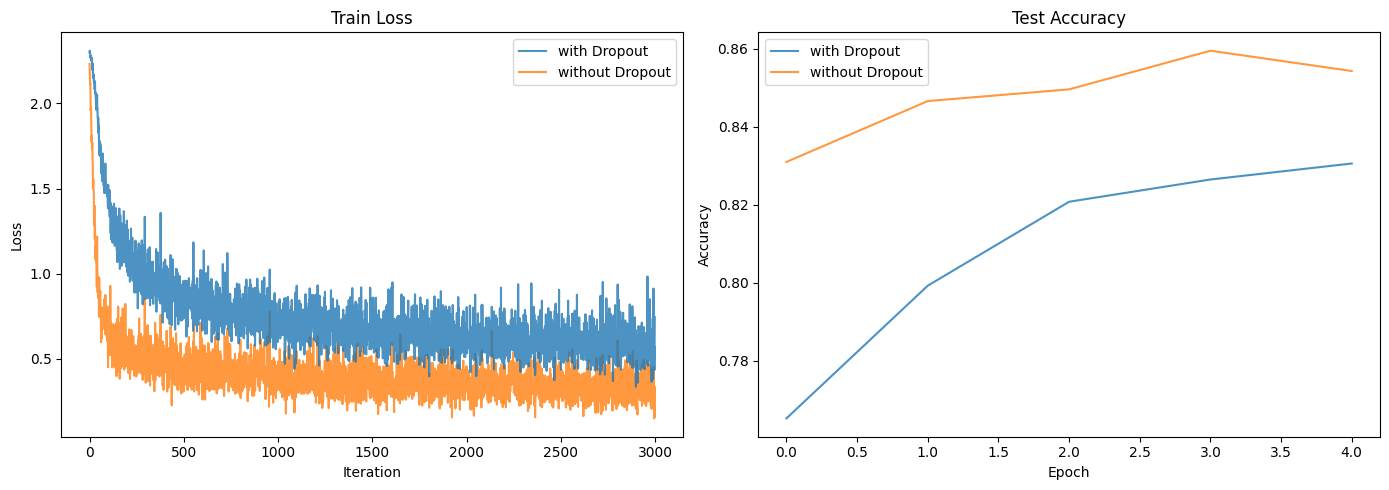

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(train_loss_list[0], label="with Dropout", alpha=0.8,zorder=2)
axes[0].plot(train_loss_list[1], label="without Dropout", alpha=0.8,zorder=1)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy 그래프
axes[1].plot(test_acc_list[0], label="with Dropout", alpha=0.8)
axes[1].plot(test_acc_list[1], label="without Dropout", alpha=0.8)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()